# Introduction
In this notebook, we will create and export a pipeline to introduce to our machine learning model.
This pipeline will perform the following actions on the following features:

| Name | Null Response | Transformation | Notes |
|---|---|---|---|
| received | 0 | Standardization | |
| delivered_to | 0 | Standardization | |
| path_length | — | Standardization | Derived from received + delivered_to |
| day_sin | — | Cyclical Encoding | Derived from day |
| day_cos | — | Cyclical Encoding | Derived from day |
| hour_sin | — | Cyclical Encoding | Derived from hour |
| hour_cos | — | Cyclical Encoding | Derived from hour |
| weekday | Most Frequent | One-Hot Encoding | |
| body | — | TF-IDF Vectorization | Turned into a sparse matrix |
| subject | — | TF-IDF Vectorization | Turned into a sparse matrix |

All other features will be dropped, as they displayed little relationship to spam classification.
> [!NOTE] Our data comes from the following dictonary:

column         | dtype  | desciption
---------------|--------|---------------------------------------------------
filename       | str    | filename of the given file
from           | str    | domain of email sender
to             | str    | domain of email recipient
return_path    | str    | domain of the return email
message_id     | str    | domain of the 'Message-Id' header
recieved       | int    | number of entries in the 'Recieved' header
deliver_to     | int    | number of entries in the 'Deliver-To' header
weekday        | str    | day of week - (mon, tue, wed, etc.)
day            | str    | DD
month          | str    | MMM
year           | int    | YYYY
timezone       | str    | timezone of datetime, in UTC offset format
subject        | object | array of words within the subject, stemmed
body           | object | array of words within the body, stemmed

## Setup

In [101]:
# use this cell to install all requirements for this project.
# !pip install -r requirements.txt

In [102]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [103]:
# make array print readable
np.set_printoptions(suppress=True, precision=4)

In [104]:
df = pd.read_csv(
    'data/processed_emails.csv', 
    index_col='filename', )
df.head()

,body,from,weekday,day,month,year,hour,timezone,to,subject,return_path,received,delivered_to,message_id,spam
filename,,,,,,,,,,,,,,,
01128.efb36914ecb55d78a894591eff0843c5,"['on', 'sun', 'NUMBER', 'jul', 'NUMBER', 'NUMB...",uni.de,sun,21,jul,2002,20,-400.0,freshrpms.net,"['re', 'ximian', 'apt', 'repo']",freshrpms.net,7,1,uni.de,False
00659.02e6dd777f837798533eae8f3b6a0491,"['what', 'is', 'mime', 'mime', 'stand', 'for',...",docserver.cac.washington.edu,mon,19,aug,2002,23,-700.0,example.sourceforge.net,"['wm', 'the', 'mime', 'inform', 'you', 'reques...",example.sourceforge.net,6,1,docserver.cac.washington.edu,False
00776.7df92458e9cf04b8873c406bde7d2fbe,"['im', 'not', 'up', 'to', 'fork', 'the', 'text...",golux.com,tue,13,aug,2002,15,-400.0,xent.com,"['a', 'messag', 'for', 'our', 'time']",xent.com,6,2,golux.com,False
00116.409b29c26edef06268b4bfa03ef1367a,"['on', 'sat', 'jul', 'NUMBER', 'NUMBER', 'at',...",skynet.ie,sat,20,jul,2002,13,100.0,linux.ie,"['re', 'ilug', 'vanquish', 'the', 'daemon', 'o...",linux.ie,8,1,skynet.ie,False
00615.23556d88fcb1179b25083cfc41017f42,"['origin', 'messag', 'date', 'thu', 'NUMBER', ...",dmv.com,thu,8,aug,2002,16,-400.0,example.sourceforge.net,"['re', 'razorus', 'use', 'razor', 'with', 'non...",example.sourceforge.net,7,1,landshark,False


In [105]:
# ugly data :(
df = df[df.weekday != 'wed29']
df = df.astype(dtype={
        'body': 'object',
        'from': 'str',
        'weekday': 'str',
        'day': 'int',
        'month': 'str',
        'hour': 'int',
        'timezone': 'object',
        'to': 'str',
        'subject': 'object',
        'return_path': 'str',
        'received': 'int',
        'delivered_to': 'int',
        'message_id': 'str',
        'spam': 'bool'
    })

# Pipeline Creation
Here, we will simply create an export a pipeline to be used in `model.ipynb`. Since this pipeline 
only serves to sample and test the pipeline, we will not split the data or worry about data leakage.

## Feature Extraction
The first step in our pipeline will be to extract features 

## Numerical Variables
We will create a process to handle `received`, `delivered_to`, and `path_length`; along with their 
respective imputations and transformations.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def create_path_length(X: np.ndarray):
    # path_length = received + delivered_to
    path_lengths = X[:, 0] + X[:, 1]
    return np.column_stack((X, path_lengths))

def num_features_names_out(function_transformer, input_features):
    return ['received', 'delivered_to', 'path_length']

num_transformer = FunctionTransformer(create_path_length, feature_names_out=num_features_names_out)

num_pipeline = Pipeline([
    ('num_impute', SimpleImputer( # 1. impute with zero
        strategy='constant',
        fill_value=0
    )),
    ('create_path_length', num_transformer), # 2. create new feature
    ('num_scale', StandardScaler()) # 3. standardize all data
],
verbose=True)


X_num = df[['received','delivered_to']]

num_trans = num_pipeline.fit_transform(X_num),
num_mask = num_pipeline.get_feature_names_out()
num_mask, num_trans

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s


(array(['received', 'delivered_to', 'path_length'], dtype=object),
 (array([[ 0.6884,  0.1248,  0.6201],
         [ 0.2698,  0.1248,  0.2624],
         [ 0.2698,  1.5267,  0.6201],
         ...,
         [ 1.9441,  1.5267,  2.051 ],
         [-0.1488,  0.1248, -0.0953],
         [-1.4045, -1.2771, -1.5262]], shape=(3044, 3)),))

## Cyclical Variables
For variables like `Day`, `Hour`, and `Weekday` which have a cyclical relationship (e.g. 00:00 and 
23:00 are closely related), we can transform our times and hours cyclically, creating new features 
called `day_sin`, `day_cos`, `hour_sin`, etc. which can properly display a cyclical relationship.

[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
['weekday_sin', 'weekday_cos', 'month_cos', 'month_sin', 'day_cos', 'day_sin']


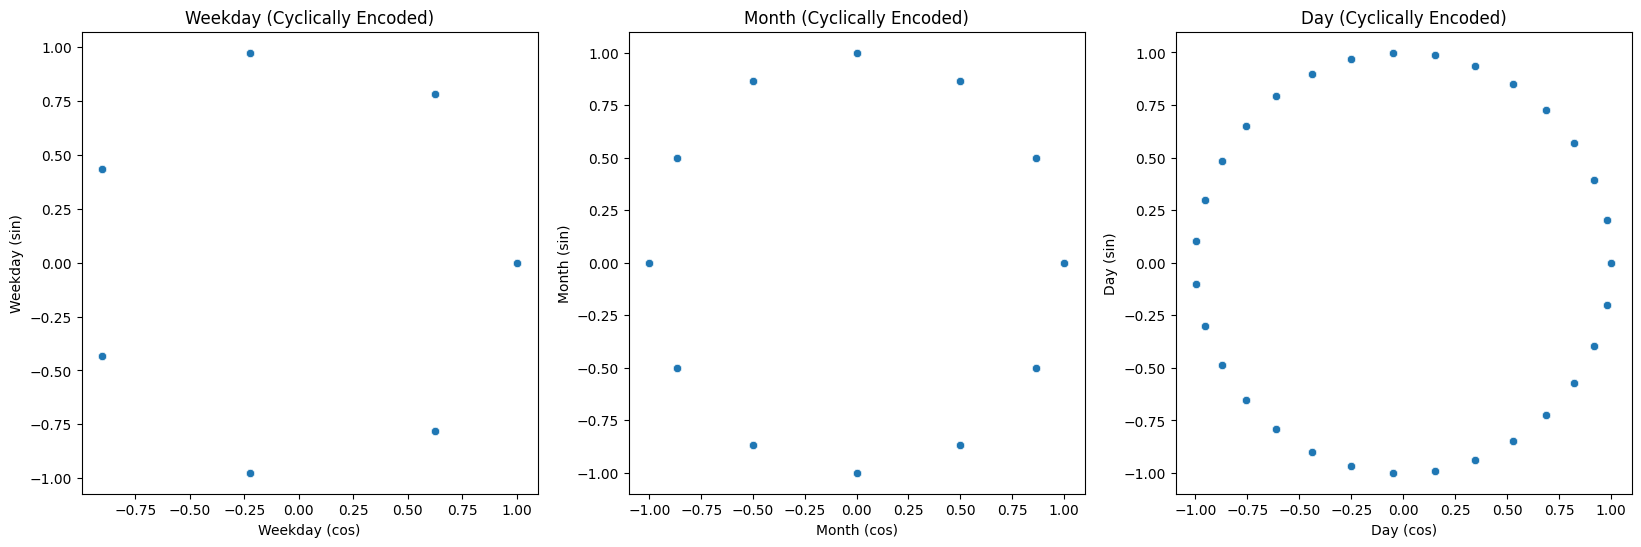

In [107]:
from sklearn.preprocessing import OrdinalEncoder

cats = [
    ['sun', 'mon', 'tue', 'wed', 'thu', 'fri', 'sat'],
    ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    ]

# -- cyclical transformation functions

def create_cat_cyclical(X: np.ndarray):
    day_N = float(len(cats[0]))
    weekday_cos = np.cos(X[:, 0] * ( 2 * np.pi / day_N))
    weekday_sin = np.sin(X[:, 0] * ( 2 * np.pi / day_N))

    month_N = float(len(cats[1]))
    month_cos = np.cos(X[:, 1] * ( 2 * np.pi / month_N))
    month_sin = np.sin(X[:, 1] * ( 2 * np.pi / month_N))
    return np.column_stack((weekday_cos, weekday_sin, month_cos, month_sin))
def cat_features_names_out(function_transformer, input_features):
    return ['weekday_sin', 'weekday_cos', 'month_cos', 'month_sin']

def create_day_cyclical(X: np.ndarray):
    N = 31 # for most scenarios, although some months do not go to 31, this is okay to use.
    # our day is on scale [1, 31], we will shift it to [0, 30].

    X = X[:] - 1
    day_cos = np.cos(X[:, 0] * ( 2 * np.pi / N))
    day_sin = np.sin(X[:, 0] * ( 2 * np.pi / N))

    return np.column_stack((day_cos, day_sin))
def day_features_names_out(function_transformer, input_features):
    return ['day_cos', 'day_sin']

transform_cat_cyclical = FunctionTransformer(create_cat_cyclical, feature_names_out=cat_features_names_out)
transform_day_cyclical = FunctionTransformer(create_day_cyclical, feature_names_out=day_features_names_out)

# -- pipelines
cat_pipeline = Pipeline([
    ('cat_impute', SimpleImputer(strategy='most_frequent')), # 1. impute weekday with most frequent if missing
    ('cat_ordinal', OrdinalEncoder(categories=cats)), # 2. Encode categorial days into ordinal
    ('cat_cyclical', transform_cat_cyclical)
],
verbose=True)

day_pipeline = Pipeline([
    ('day_impute', SimpleImputer(strategy='most_frequent')),
    ('day_cyclical', transform_day_cyclical)
], verbose=True)

# -- testing
X_cat = df[['weekday', 'month']]
X_day = df[['day']]

cat_trans = cat_pipeline.fit_transform(X_cat)
cat_mask = cat_pipeline.get_feature_names_out()
day_trans = day_pipeline.fit_transform(X_day)
day_mask = day_pipeline.get_feature_names_out()

print(np.concat((cat_mask, day_mask)).tolist())
# -- plot transformations
_, axes = plt.subplots(ncols=3, figsize=(20, 6))

sns.scatterplot(x=cat_trans[:,0], y=cat_trans[:, 1], ax=axes[0])
axes[0].set(title='Weekday (Cyclically Encoded)', xlabel='Weekday (cos)', ylabel='Weekday (sin)')

sns.scatterplot(x=cat_trans[:,2], y=cat_trans[:, 3], ax=axes[1])
axes[1].set(title='Month (Cyclically Encoded)', xlabel='Month (cos)', ylabel='Month (sin)')

sns.scatterplot(x=day_trans[:,0], y=day_trans[:, 1], ax=axes[2])
axes[2].set(title='Day (Cyclically Encoded)', xlabel='Day (cos)', ylabel='Day (sin)')
plt.show()

## Objects (Sparse Matrices)
Here, we will create pipelines to prepare and create sparse matrices for both `Body` and `Subject`.
These pipelines will allow for optimization with `max_features`, since this can drastically change
the outcome of our models performance. We can use this to properly balance complexity and 
performance when we begin model and feature optimization.

In [108]:
def analyze_sparse_matrix(sparse_matrix, mask):
    # print row of matrix
    X_0 = pd.Series(
        sparse_matrix[0].toarray().flatten(),
        mask   
    )
    
    print('-------- example row --------')
    print(X_0)

    freq = pd.Series(
        np.asarray(sparse_matrix.sum(axis=0)).flatten(),
        index=mask
    ).sort_values(ascending=False)

    print('-------- frequencies --------')
    print(freq.iloc[:10])

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
import ast

# -- transformation functions (typically lists are stored as objects primarily)
def create_list(X: pd.DataFrame):
    # assume: 
    # 1. we are in the first step (still a dataframe)
    # 2. desired value is in iloc[:,0]

    # pickle workaround, normally this would be a lambda function but you cannot pkl lambda functions
    def unpack(row):
        if (isinstance(row, str) and len(row) > 0):
            return ast.literal_eval(row)
        else:
            return []

    X = X.iloc[:,0].apply(unpack)
    corpus = X.to_list()
    return corpus

def text_features_names_out(function_transformer, input_features):
    return input_features

transform_text = FunctionTransformer(create_list, feature_names_out=text_features_names_out)

# pkl workarounds
def do_nothing(x):
    return x

# -- pipeline
text_pipeline = Pipeline([
    ('text_create_list', transform_text),
    ('text_sparse', TfidfVectorizer(
        analyzer='word',
        tokenizer=do_nothing,
        preprocessor=do_nothing,
        token_pattern=None,
        min_df=.05, # ignore words in fewer than 5% of emails
        max_df= .95, # ignore words in more than 95% of emails
        max_features=100 # get top 100 words
    ))
], verbose=True)

# -- testing

X_body = df[['body']]
X_subject = df[['subject']]

body_trans = text_pipeline.fit_transform(X_body)
body_mask = text_pipeline.get_feature_names_out()

subject_trans = text_pipeline.fit_transform(X_subject)
subject_mask = text_pipeline.get_feature_names_out()

print('--- body ---')
analyze_sparse_matrix(body_trans, body_mask)
print('\n--- subject ---')
analyze_sparse_matrix(subject_trans, subject_mask)

[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
--- body ---
-------- example row --------
NUMBER     0.282128
URL        0.345098
a          0.069643
about      0.000000
address    0.000000
             ...   
with       0.000000
work       0.065856
would      0.347531
you        0.000000
your       0.000000
Length: 100, dtype: float64
-------- frequencies --------
NUMBER    727.151563
the       716.005206
to        596.115645
a         432.560186
and       429.445454
of        371.522429
you       369.075783
i         304.470960
for       300.666271
URL       299.714710
dtype: float64

--- subject ---
-------- example row --------
NUMBER    0.0
a         0.0
for       0.0
ilug      0.0
re        1.0
the       0.0
to        0.0
your      0.0
dtype: floa

## Complete Transformation Pipeline

In [110]:
from sklearn.compose import ColumnTransformer

pipeline = ColumnTransformer([
    ('num', num_pipeline, ['received','delivered_to']),
    ('cat', cat_pipeline, ['weekday', 'month']),
    ('day', day_pipeline, ['day']),
    ('body', text_pipeline, ['body']),
    ('subject', text_pipeline, ['subject'])
    ],
    verbose=True,
    remainder='drop',
    verbose_feature_names_out=True
)

trans = pipeline.fit_transform(df)

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[ColumnTransformer] ........... (1 of 5) Processing num, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[ColumnTransformer] ........... (2 of 5) Processing cat, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[ColumnTransformer] ........... (3 of 5) Processing day, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[ColumnTransformer] .......... (4 of 5) Processing body, total=   1.4s
[Pipel

In [111]:
pipeline.get_feature_names_out()

array(['num__received', 'num__delivered_to', 'num__path_length',
       'cat__weekday_sin', 'cat__weekday_cos', 'cat__month_cos',
       'cat__month_sin', 'day__day_cos', 'day__day_sin', 'body__NUMBER',
       'body__URL', 'body__a', 'body__about', 'body__address',
       'body__all', 'body__also', 'body__an', 'body__and', 'body__ani',
       'body__are', 'body__as', 'body__at', 'body__be', 'body__been',
       'body__busi', 'body__but', 'body__by', 'body__can', 'body__click',
       'body__compani', 'body__do', 'body__dont', 'body__email',
       'body__file', 'body__for', 'body__free', 'body__from', 'body__get',
       'body__has', 'body__have', 'body__here', 'body__how', 'body__i',
       'body__if', 'body__in', 'body__inform', 'body__is', 'body__it',
       'body__just', 'body__like', 'body__list', 'body__mail',
       'body__make', 'body__me', 'body__messag', 'body__more', 'body__my',
       'body__need', 'body__new', 'body__no', 'body__not', 'body__now',
       'body__of', 'body_

In [112]:
print(trans[0])

[ 0.6884  0.1248  0.6201  1.      0.     -1.      0.     -0.6121 -0.7908
  0.2821  0.3451  0.0696  0.      0.      0.0521  0.      0.      0.1048
  0.      0.0483  0.      0.      0.0866  0.      0.      0.1171  0.
  0.      0.      0.      0.      0.1361  0.      0.      0.1093  0.
  0.0444  0.0566  0.      0.0475  0.0578  0.0696  0.5594  0.0987  0.0389
  0.      0.      0.1684  0.1208  0.0655  0.089   0.1095  0.      0.
  0.      0.      0.0653  0.0694  0.      0.      0.      0.      0.1125
  0.0413  0.      0.065   0.      0.      0.      0.      0.      0.1634
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.1713  0.1652  0.      0.      0.0704  0.0396
  0.0645  0.258   0.      0.      0.0577  0.      0.0707  0.      0.
  0.      0.      0.      0.      0.      0.      0.0659  0.3475  0.
  0.      0.      0.      0.      0.      1.      0.      0.      0.    ]


# Conclusion
Here we conclude our feature transformation pipeline. Next, we will export this pipeline using
`joblib`, for use in [models.ipynb](models.ipynb). In [models.ipynb](models.ipynb), we will conduct
model selection, feature tuning, and model tuning. 

In [116]:
import cloudpickle as cp

with open('objects/feature_pipeline.pkl', 'wb') as f:
    cp.dump(pipeline, f)

In [117]:
# aside: for simplicity, we will dump the cleaned df as well (removed some unchecked, messy data)
df.to_csv('data/cleaned_emails.csv')